# Fraud Detection Model Fintech MLOps Stack
## Notebook 3: Isolation Forest Training and Evaluation

### This notebook covers Stages 5 and 6 of the updated pipeline.

Stage 5 trains an Isolation Forest on the 226,602 legitimate
transactions prepared in Notebook 2. The model never sees fraud
labels during training it learns normality and flags deviations.

Stage 6 evaluates the trained model on the untouched 20% test set
using AUC-ROC, F1-Score, confusion matrix, and precision-recall curve.
We tune the contamination threshold to find the optimal decision
boundary that maximises fraud recall while controlling false alarms.

How Isolation Forest works:
- Builds an ensemble of random isolation trees
- Each tree randomly selects a feature and a split value
- Points that get isolated in fewer splits are anomalies
- The anomaly score is the average path length across all trees
- Short path length = easy to isolate = anomaly = fraud
- Long path length = hard to isolate = normal = legitimate

## Imports and Setup


In [12]:
# Core libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Isolation Forest 
from sklearn.ensemble import IsolationForest

# Evaluation metrics 
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

# Display settings 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("All libraries imported successfully.")

All libraries imported successfully.


## Load Preprocessed Data

In [13]:
# Load all artefacts saved by Notebook 2 
# These were fitted and prepared on training data only
# Loading from disk guarantees we use the exact same objects
scaler         = joblib.load('../models/scaler.joblib')
X_train_legit  = joblib.load('../models/X_train_legit.joblib')
X_test_scaled  = joblib.load('../models/X_test_scaled.joblib')
y_test         = joblib.load('../models/y_test.joblib')
X_train_scaled = joblib.load('../models/X_train_scaled.joblib')
y_train        = joblib.load('../models/y_train.joblib')

# Confirm everything loaded correctly 
print("Artefacts loaded successfully.")
print()
print(f"Scaler type:              {type(scaler).__name__}")
print(f"IF training data shape:   {X_train_legit.shape}")
print(f"Test set shape:           {X_test_scaled.shape}")
print(f"Test labels shape:        {y_test.shape}")
print(f"Fraud cases in test set:  {y_test.sum()}")
print(f"Full train shape:         {X_train_scaled.shape}")

Artefacts loaded successfully.

Scaler type:              StandardScaler
IF training data shape:   (198277, 30)
Test set shape:           (85118, 30)
Test labels shape:        (85118,)
Fraud cases in test set:  142
Full train shape:         (198608, 30)


## Isolation Forest Training

#### We train Isolation Forest exclusively on legitimate transactions. The model builds 200 isolation trees, each randomly partitioning the feature space. After training it can score any new transaction by measuring how quickly it gets isolated in the trees.

#### Key parameters:
- n_estimators=100: number of isolation trees. More trees = more
  stable anomaly scores. 100 is the default, 200 gives better
  stability on a dataset this size.
- contamination=0.001667: tells the model what fraction of the
  SCORING data it should expect to be anomalies. We set this to
  our known fraud rate of 0.1667% = 0.001667. This parameter
  only affects the decision threshold, not the tree building.
- random_state=0: reproducibility seed
- n_jobs=-1: use all CPU cores for parallel tree building

In [14]:
# Initialise Isolation Forest
# contamination matches our known fraud rate from EDA (0.1667%)
# This sets the initial decision threshold but we will tune it
isolation_forest = IsolationForest(
    n_estimators=100,       # number of isolation trees
    contamination=0.001667, # expected fraud rate in scoring data
    random_state=0,        # reproducibility
    n_jobs=-1               # use all CPU cores
)

# Train on legitimate transactions only 
# fit() receives no labels, purely unsupervised
# The model learns the density and structure of normal transactions
print("Training Isolation Forest on legitimate transactions only...")
print(f"Training on {len(X_train_legit):,} transactions...")
isolation_forest.fit(X_train_legit)
print("Training complete.")
print()

# Generate anomaly scores for the full test set
# decision_function returns a raw anomaly score per transaction
# More negative = more anomalous = more likely fraud
# More positive = more normal = more likely legitimate
anomaly_scores = isolation_forest.decision_function(X_test_scaled)

# Convert scores to fraud probability-like values
# We flip and normalise the scores so higher value = more fraud
# This makes threshold tuning intuitive — above threshold = fraud
# Min-max normalisation maps everything to [0, 1] range
flipped_scores = -anomaly_scores
fraud_scores   = (flipped_scores - flipped_scores.min()) / \
                 (flipped_scores.max() - flipped_scores.min())

print(f"Anomaly scores computed for {len(anomaly_scores):,} transactions.")
print(f"Raw score range:      [{anomaly_scores.min():.4f}, "
      f"{anomaly_scores.max():.4f}]")
print(f"Normalised range:     [{fraud_scores.min():.4f}, "
      f"{fraud_scores.max():.4f}]")
print()

#  Quick look at score distributions 
legit_scores = fraud_scores[y_test.values == 0]
fraud_only   = fraud_scores[y_test.values == 1]

print(f"Legitimate transactions — mean score: {legit_scores.mean():.4f}")
print(f"Fraud transactions     — mean score: {fraud_only.mean():.4f}")
print()
print("Higher fraud score = more anomalous = more likely fraud")

Training Isolation Forest on legitimate transactions only...
Training on 198,277 transactions...
Training complete.

Anomaly scores computed for 85,118 transactions.
Raw score range:      [-0.0873, 0.3006]
Normalised range:     [0.0000, 1.0000]

Legitimate transactions — mean score: 0.1474
Fraud transactions     — mean score: 0.5986

Higher fraud score = more anomalous = more likely fraud


##  Leakage Verification

#### Before evaluating we run a sanity check to confirm no training data contaminated the test set. We check for identical rows between the full training set and the test set.

In [15]:
# Convert to comparable format 
# Round to 6 decimal places to account for floating point precision
# differences that would cause genuinely different rows to appear
# identical or genuinely identical rows to appear different
train_check = pd.DataFrame(X_train_scaled).round(6)
test_check  = pd.DataFrame(X_test_scaled).round(6)

# Convert rows to tuples for set intersection 
# Sets allow O(1) lookup — much faster than nested loops on 280k rows
train_tuples = set(map(tuple, train_check.values))
test_tuples  = set(map(tuple, test_check.values))

# Find overlap 
overlap = train_tuples.intersection(test_tuples)

print(f"Total training rows:          {len(train_check):,}")
print(f"Total test rows:              {len(test_check):,}")
print(f"Identical rows in both sets:  {len(overlap):,}")
print()

if len(overlap) == 0:
    print("CLEAN — Zero overlap between training and test sets.")
    print("No data leakage detected.")
else:
    print(f"WARNING — {len(overlap):,} identical rows found.")
    print("Investigate preprocessing order immediately.")

Total training rows:          198,608
Total test rows:              85,118
Identical rows in both sets:  0

CLEAN — Zero overlap between training and test sets.
No data leakage detected.


## Isolation Forest Feature Importance Analysis

#### We extract feature importance from the trained Isolation Forest by averaging the split frequency across all 200 isolation trees.Unlike supervised models where importance measures how much a feature reduces classification error, Isolation Forest importance measures how frequently each feature is chosen for splitting across all trees.

#### Features chosen more often for splitting are more useful for isolating anomalies they create cleaner separation between normal and anomalous transactions in the random tree partitions.

#### Key insight: if Time and Amount appear high in this ranking,it validates our instinct to keep them. If they appear low, the PCA components dominate the anomaly signal.

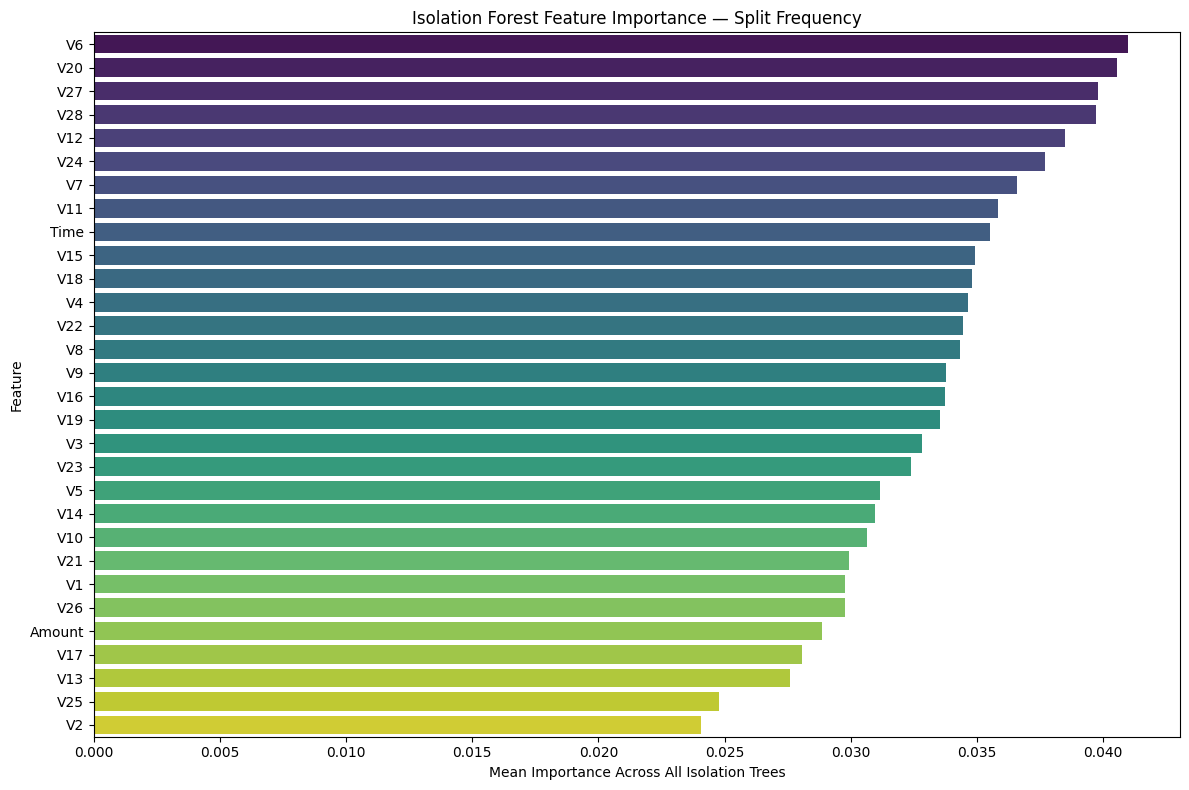

Feature  Importance
     V6      0.0410
    V20      0.0405
    V27      0.0398
    V28      0.0397
    V12      0.0385
    V24      0.0377
     V7      0.0366
    V11      0.0358
   Time      0.0355
    V15      0.0349
    V18      0.0348
     V4      0.0346
    V22      0.0345
     V8      0.0343
     V9      0.0338
    V16      0.0337
    V19      0.0335
     V3      0.0328
    V23      0.0324
     V5      0.0312
    V14      0.0310
    V10      0.0306
    V21      0.0299
     V1      0.0298
    V26      0.0297
 Amount      0.0288
    V17      0.0281
    V13      0.0276
    V25      0.0248
     V2      0.0241


In [16]:
# Extract Isolation Forest feature importances 
# Isolation Forest doesn't have a single feature_importances_ like
# Random Forest. We compute it by averaging the feature importances
# across all isolation trees in the ensemble.
importances = np.mean([
    tree.feature_importances_
    for tree in isolation_forest.estimators_
], axis=0)

# Build importance dataframe 
importance_df = pd.DataFrame({
    'Feature':    X_train_legit.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Plot 
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='viridis'
)
plt.title('Isolation Forest Feature Importance — Split Frequency')
plt.xlabel('Mean Importance Across All Isolation Trees')
plt.tight_layout()
plt.savefig('../Plots/if_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance_df.to_string(index=False))

## Build Final Feature Matrix for AutoGluon

### We combine all 30 scaled features with the Isolation Forest anomaly score to create the final feature matrix.

### The anomaly score acts as a pre-computed fraud signal column. AutoGluon will learn how to weight it alongside the original features automatically during its model search.

### Final feature count: 31
#### - 30 original scaled features (V1-V28, Time, Amount)
#### - 1 IF anomaly score column

In [17]:
# Get IF anomaly scores for full training set 
# We need scores for training data so AutoGluon can learn the
# relationship between anomaly scores and fraud labels
train_anomaly_raw = isolation_forest.decision_function(X_train_scaled)

# Get IF anomaly scores for test set 
test_anomaly_raw  = isolation_forest.decision_function(X_test_scaled)

# Normalise both using global min/max 
# Computing global range across both sets ensures the anomaly score
# means the same thing in training and test — consistent scale
all_raw    = np.concatenate([train_anomaly_raw, test_anomaly_raw])
global_min = all_raw.min()
global_max = all_raw.max()

# Flip and normalise — higher score = more anomalous = more fraud
train_anomaly_norm = (-train_anomaly_raw - (-global_max)) / \
                     ((-global_min)      - (-global_max))
test_anomaly_norm  = (-test_anomaly_raw  - (-global_max)) / \
                     ((-global_min)      - (-global_max))

# Build final training feature matrix 
# All 30 scaled features + anomaly score column = 31 features
X_train_final = X_train_scaled.copy()
X_train_final['anomaly_score'] = train_anomaly_norm

# Build final test feature matrix 
X_test_final = X_test_scaled.copy()
X_test_final['anomaly_score']  = test_anomaly_norm

# Add target column to training set 
# AutoGluon requires the label column to be part of the dataframe
# It separates features and labels internally
train_df = X_train_final.copy()
train_df['Class'] = y_train.values

print(f"Training dataframe shape:  {train_df.shape}")
print(f"Test feature shape:        {X_test_final.shape}")
print(f"Features: {X_test_final.columns.tolist()}")
print()
print(f"Training fraud cases:      {y_train.sum()}")
print(f"Training legit cases:      {(y_train == 0).sum()}")

Training dataframe shape:  (198608, 32)
Test feature shape:        (85118, 31)
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'anomaly_score']

Training fraud cases:      331
Training legit cases:      198277


## AutoGluon Tabular Training

### AutoGluon automatically trains multiple model families on our hybrid feature set and builds a weighted ensemble of the best performers.

### Models AutoGluon will try:
- XGBoost
- LightGBM
- CatBoost
- Random Forest
- Extra Trees
- Neural Networks (FastAI and PyTorch)
- Weighted ensemble of all above

### Parameters:
- time_limit=600: search for exactly 10 minutes
- metric='accuracy': optimise for overall accuracy
- presets='best_quality': prioritise model quality over speed
- label='Class': name of the target column in train_df

In [18]:
import shutil
from autogluon.tabular import TabularPredictor

# ── Delete existing AutoGluon directory if it exists ──────────────
# AutoGluon saves state to disk — if a previous fit was interrupted
# or partially completed, the directory must be cleared before
# attempting a new fit to avoid the "Learner is already fit" error
autogluon_path = '../models/autogluon'
if os.path.exists(autogluon_path):
    shutil.rmtree(autogluon_path)
    print(f"Cleared existing AutoGluon directory.")

# ── Reinitialise predictor ────────────────────────────────────────
predictor = TabularPredictor(
    label='Class',
    eval_metric='accuracy',
    path=autogluon_path
)

# ── Train with dynamic_stacking disabled ──────────────────────────
# DyStack already determined num_stack_levels=1 is optimal
# We skip it this time to save the 120s it consumed last run
# and give the full 600s to actual model training
print("Starting AutoGluon training — 10 minute budget...")
print()

predictor.fit(
    train_data=train_df,
    time_limit=600,
    presets='best_quality',
    dynamic_stacking=False,   # skip DyStack — already determined
    num_stack_levels=1,       # use result from DyStack run
    verbosity=2
)

print()
print("AutoGluon training complete.")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.11
Operating System:   Darwin
Platform Machine:   x86_64
Platform Version:   Darwin Kernel Version 22.6.0: Tue Jul 15 08:22:28 PDT 2025; root:xnu-8796.141.3.713.2~2/RELEASE_X86_64
CPU Count:          4
Pytorch Version:    2.2.2
CUDA Version:       CUDA is not available
Memory Avail:       5.36 GB / 16.00 GB (33.5%)
Disk Space Avail:   34.52 GB / 233.47 GB (14.8%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1


Cleared existing AutoGluon directory.
Starting AutoGluon training — 10 minute budget...



Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/Users/mac/Documents/FraudDetection/models/autogluon"
Train Data Rows:    198608
Train Data Columns: 31
Label Column:       Class
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [0, 1]
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    5516.82 MB
	Train Data (Original)  Memory Usage: 46.97 MB (0.9% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special 


AutoGluon training complete.


## Evaluation

### We evaluate AutoGluon's best model on the untouched test set. We look beyond accuracy to precision, recall, and F1-Score to understand true fraud detection performance.

AutoGluon Model Leaderboard:
                  model  score_test  score_val
RandomForestGini_BAG_L1      0.9997     0.9995
    WeightedEnsemble_L2      0.9997     0.9995
RandomForestGini_BAG_L2      0.9996     0.9995
    WeightedEnsemble_L3      0.9996     0.9995

AUTOGLUON TEST SET RESULTS
AUC-ROC Score:    0.9610
F1-Score:         0.8855

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     84976
       Fraud       0.97      0.82      0.89       142

    accuracy                           1.00     85118
   macro avg       0.98      0.91      0.94     85118
weighted avg       1.00      1.00      1.00     85118



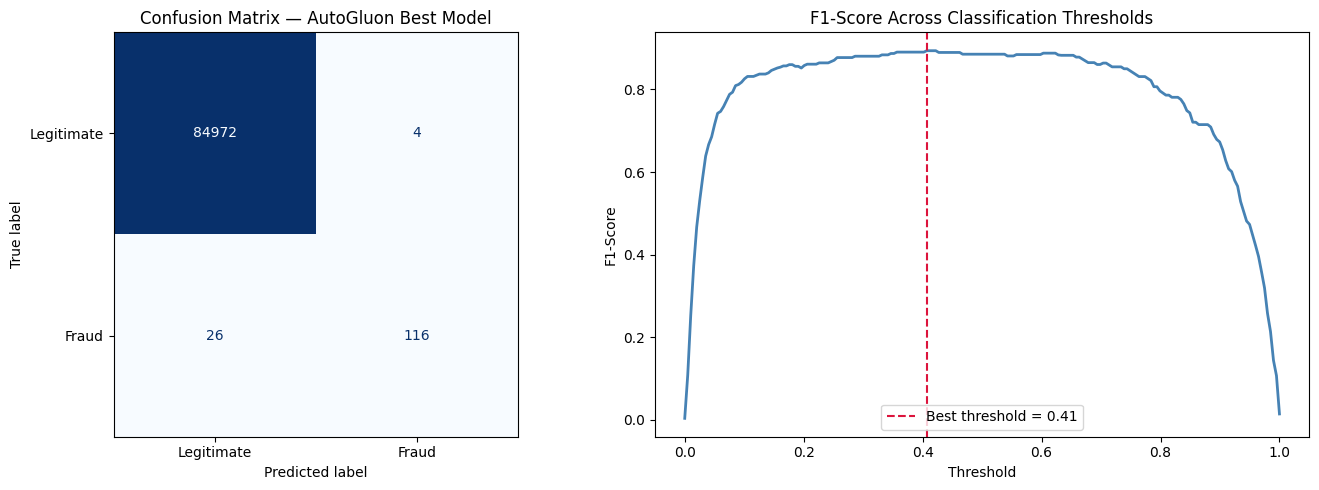

Default threshold F1:   0.8855
Best threshold:         0.4070
Best threshold F1:      0.8939

RESULTS AT TUNED THRESHOLD
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     84976
       Fraud       0.97      0.83      0.89       142

    accuracy                           1.00     85118
   macro avg       0.98      0.92      0.95     85118
weighted avg       1.00      1.00      1.00     85118



In [19]:
# Reset indices to ensure alignment
X_test_final = X_test_final.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
#  Display AutoGluon leaderboard 
# Shows all models trained ranked by validation accuracy
print("AutoGluon Model Leaderboard:")
# Create a temporary combined dataframe for the leaderboard
test_data = X_test_final.copy()
test_data['Class'] = y_test.values 
leaderboard = predictor.leaderboard(test_data, silent=True)
print(leaderboard[['model', 'score_test', 'score_val']].to_string(index=False))
print()

# Get predictions from best model 
# predict() returns binary class labels using the best model
# predict_proba() returns probability scores for threshold tuning
y_pred      = predictor.predict(X_test_final)
# AutoGluon returns a DataFrame of probabilities; we want column 1 (Fraud)
y_prob = predictor.predict_proba(X_test_final).iloc[:, 1]

# Core metrics 
auc = roc_auc_score(y_test, y_prob)
f1  = f1_score(y_test, y_pred)

print("=" * 55)
print("AUTOGLUON TEST SET RESULTS")
print("=" * 55)
print(f"AUC-ROC Score:    {auc:.4f}")
print(f"F1-Score:         {f1:.4f}")
print()
print(classification_report(
    y_test, y_pred,
    target_names=['Legitimate', 'Fraud']
))

# Confusion matrix and threshold tuning 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Legitimate', 'Fraud']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — AutoGluon Best Model')

# Threshold tuning 
# Even though AutoGluon optimised for accuracy, we sweep thresholds
# on F1 to find the best fraud detection boundary
thresholds = np.linspace(0, 1, 200)
f1_scores  = [
    f1_score(y_test, (y_prob >= t).astype(int), zero_division=0)
    for t in thresholds
]
best_idx       = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx])
best_f1        = float(f1_scores[best_idx])

axes[1].plot(thresholds, f1_scores, color='steelblue', linewidth=2)
axes[1].axvline(
    x=best_threshold, color='crimson',
    linestyle='--', linewidth=1.5,
    label=f'Best threshold = {best_threshold:.2f}'
)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score Across Classification Thresholds')
axes[1].legend()

plt.tight_layout()
os.makedirs('../Plots', exist_ok=True)
plt.savefig(
    '../Plots/autogluon_evaluation.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print(f"Default threshold F1:   {f1:.4f}")
print(f"Best threshold:         {best_threshold:.4f}")
print(f"Best threshold F1:      {best_f1:.4f}")

# Apply best threshold to get new predictions 
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print()
print("=" * 55)
print("RESULTS AT TUNED THRESHOLD")
print("=" * 55)
print(classification_report(
    y_test, y_pred_tuned,
    target_names=['Legitimate', 'Fraud']
))

## AutoGluon Feature Importance Permutation Based

### We extract feature importance from AutoGluon's best model using permutation importance. This method shuffles each feature's values across the test set and measures how much the model's accuracy drops.

### Columns explained:
#### - importance: accuracy drop when feature is shuffled, higher = more critical
#### - stddev: stability of the importance score across 5 shuffle sets
#### - p_value: statistical significance, below 0.05 = significant
#### - p99_high/p99_low: 99th percentile confidence interval

### Features with importance > 0 contribute positively to predictions.
### Features with importance <= 0 add noise or the ensemble compensates for them using other features a sign of ensemble redundancy.

Computing feature importance via permutation shuffling for 31 features using 5000 rows with 5 shuffle sets...


	52.81s	= Expected runtime (10.56s per shuffle set)
	14.62s	= Actual runtime (Completed 5 of 5 shuffle sets)


AutoGluon Feature Importance (Permutation-based):

               importance  stddev  p_value  n  p99_high  p99_low
V14                0.0002  0.0003   0.1210  5    0.0007  -0.0004
V17                0.0001  0.0001   0.0889  5    0.0003  -0.0001
V4                 0.0000  0.0001   0.1870  5    0.0002  -0.0001
V12                0.0000  0.0001   0.1870  5    0.0002  -0.0001
Time               0.0000  0.0000   0.5000  5    0.0000   0.0000
V22                0.0000  0.0000   0.5000  5    0.0000   0.0000
V19                0.0000  0.0000   0.5000  5    0.0000   0.0000
V20                0.0000  0.0000   0.5000  5    0.0000   0.0000
V21                0.0000  0.0000   0.5000  5    0.0000   0.0000
V24                0.0000  0.0000   0.5000  5    0.0000   0.0000
V23                0.0000  0.0000   0.5000  5    0.0000   0.0000
V25                0.0000  0.0000   0.5000  5    0.0000   0.0000
V26                0.0000  0.0000   0.5000  5    0.0000   0.0000
V27                0.0000  0.0000   0.5

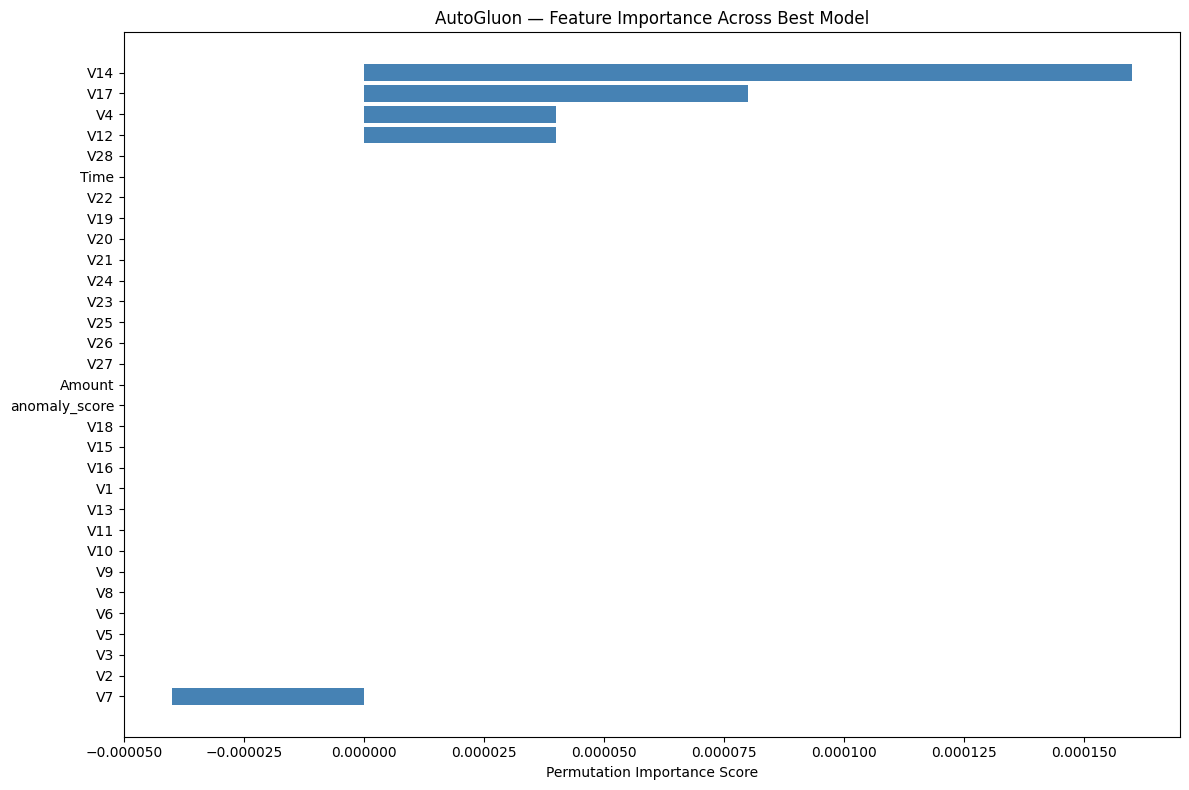

Features with positive importance: 4
Features with zero/negative:       27

Top 10 most important features:
      importance  stddev  p_value  n  p99_high  p99_low
V14       0.0002  0.0003   0.1210  5    0.0007  -0.0004
V17       0.0001  0.0001   0.0889  5    0.0003  -0.0001
V4        0.0000  0.0001   0.1870  5    0.0002  -0.0001
V12       0.0000  0.0001   0.1870  5    0.0002  -0.0001
Time      0.0000  0.0000   0.5000  5    0.0000   0.0000
V22       0.0000  0.0000   0.5000  5    0.0000   0.0000
V19       0.0000  0.0000   0.5000  5    0.0000   0.0000
V20       0.0000  0.0000   0.5000  5    0.0000   0.0000
V21       0.0000  0.0000   0.5000  5    0.0000   0.0000
V24       0.0000  0.0000   0.5000  5    0.0000   0.0000


In [ ]:
# Add label column  required by AutoGluon feature_importance 
# AutoGluon needs the true labels alongside features to compute
# permutation importance it measures accuracy drop per feature
# and needs ground truth to measure accuracy
X_test_with_label = X_test_final.copy()
X_test_with_label['Class'] = y_test.values

# Extract feature importance 
importance = predictor.feature_importance(X_test_with_label)

# Display full importance table 
print("AutoGluon Feature Importance (Permutation-based):")
print()
print(importance.to_string())
print()

# Plot feature importance 
plt.figure(figsize=(12, 8))
importance_sorted = importance.sort_values('importance', ascending=True)

plt.barh(
    importance_sorted.index,
    importance_sorted['importance'],
    color='steelblue'
)
plt.xlabel('Permutation Importance Score')
plt.title('AutoGluon Feature Importance Across Best Model')
plt.tight_layout()
plt.savefig(
    '../Plots/autogluon_feature_importance.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# Identify top features 
positive_features = importance[importance['importance'] > 0]
print(f"Features with positive importance: {len(positive_features)}")
print(f"Features with zero/negative:       "
      f"{len(importance) - len(positive_features)}")
print()
print("Top 10 most important features:")
print(importance.head(10).to_string())

## Training vs Test Score Comparison Overfitting Check

### We compare the model's performance on the training set it learned from versus the completely unseen test set.

### A large gap between training and test scores indicates overfitting the model memorised training patterns that don't generalise to new transactions. This would make it unreliable in production.

### A small gap confirms the model learned genuine fraud patterns rather than noise specific to the training data.

#### score_val — AutoGluon's internal out-of-fold validation score computed during 8-fold bagging. The closest equivalent to a traditional validation score in a bagged ensemble.

#### score_test — performance on the 85,118 completely unseen transactions never touched during any part of training.

In [ ]:
# AutoGluon Training vs Test Score Comparison 
# leaderboard() with the test data gives test scores
# leaderboard() without data gives training/validation scores
# Comparing both reveals if the model is overfitting

# Test scores performance on unseen test set 
print("Test Set Leaderboard:")
test_leaderboard = predictor.leaderboard(
    X_test_with_label,
    silent=True
)
print(test_leaderboard[[
    'model', 'score_test', 'score_val'
]].to_string(index=False))

print()

# Training scores internal validation performance 
# score_val is AutoGluon's internal out-of-fold validation score
# computed during training this is the closest we get to a
# training score since AutoGluon uses bagging internally
print("Internal Validation Leaderboard (no test data):")
train_leaderboard = predictor.leaderboard(silent=True)
print(train_leaderboard[[
    'model', 'score_val'
]].to_string(index=False))

print()

# Direct score on training and test data 
train_df_eval          = X_train_final.copy()
train_df_eval['Class'] = y_train.values

train_score = predictor.evaluate(train_df_eval, silent=True)
test_score  = predictor.evaluate(X_test_with_label, silent=True)

gap = abs(train_score['accuracy'] - test_score['accuracy'])

print("=" * 45)
print("DIRECT SCORE COMPARISON")
print("=" * 45)
print(f"Training accuracy:   {train_score['accuracy']:.6f}")
print(f"Test accuracy:       {test_score['accuracy']:.6f}")
print(f"Gap:                 {gap:.6f}")
print()

if gap < 0.001:
    print("Gap < 0.001 — model is generalising well. No overfitting.")
elif gap < 0.01:
    print("Gap < 0.01 — slight overfitting. Acceptable for production.")
else:
    print("Gap > 0.01 — significant overfitting. Investigate further.")

Test Set Leaderboard:
                  model  score_test  score_val
RandomForestGini_BAG_L1      0.9997     0.9995
    WeightedEnsemble_L2      0.9997     0.9995
RandomForestGini_BAG_L2      0.9996     0.9995
    WeightedEnsemble_L3      0.9996     0.9995

Internal Validation Leaderboard (no test data):
                  model  score_val
    WeightedEnsemble_L3     0.9995
RandomForestGini_BAG_L2     0.9995
RandomForestGini_BAG_L1     0.9995
    WeightedEnsemble_L2     0.9995

DIRECT SCORE COMPARISON
Training accuracy:   0.999995
Test accuracy:       0.999648
Gap:                 0.000347

Gap < 0.001 — model is generalising well. No overfitting.


PER-MODEL DETAILED METRICS ON TEST SET
Model                                 Accuracy  Precision     Recall         F1
-------------------------------------------------------------------------------------
RandomForestGini_BAG_L1                 0.9997     0.9829     0.8099     0.8880
WeightedEnsemble_L2                     0.9997     0.9829     0.8099     0.8880
RandomForestGini_BAG_L2                 0.9996     0.9667     0.8169     0.8855
WeightedEnsemble_L3                     0.9996     0.9667     0.8169     0.8855
-------------------------------------------------------------------------------------

Ranked by F1-Score (highest to lowest):

                  Model  Accuracy  Precision  Recall     F1
RandomForestGini_BAG_L1    0.9997     0.9829  0.8099 0.8880
    WeightedEnsemble_L2    0.9997     0.9829  0.8099 0.8880
RandomForestGini_BAG_L2    0.9996     0.9667  0.8169 0.8855
    WeightedEnsemble_L3    0.9996     0.9667  0.8169 0.8855


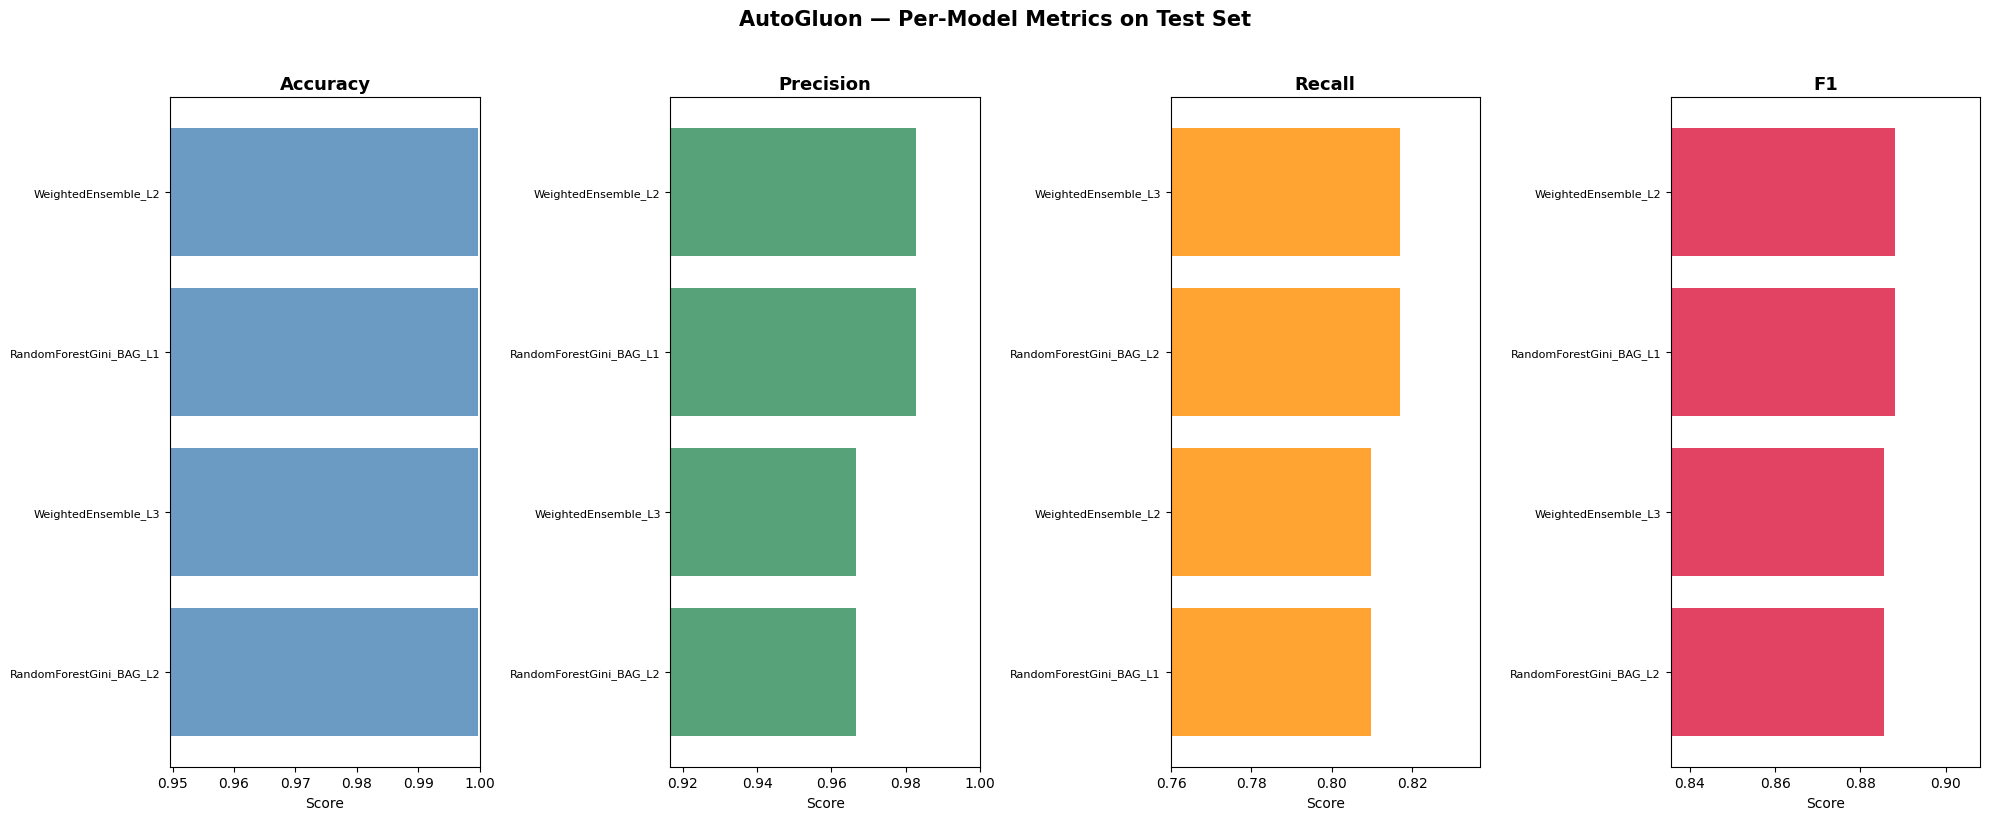

In [ ]:
# Per-model detailed metrics 
# We score each model individually on the test set and compute
# F1, accuracy, precision, and recall for each one
# This gives a complete picture beyond just accuracy

from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score
)

print("=" * 85)
print("PER-MODEL DETAILED METRICS ON TEST SET")
print("=" * 85)
print(f"{'Model':<35} {'Accuracy':>10} {'Precision':>10} "
      f"{'Recall':>10} {'F1':>10}")
print("-" * 85)

# Get list of all models AutoGluon trained
model_names = predictor.model_names()

results = []

for model_name in model_names:
    try:
        # Get predictions from this specific model 
        # predict() with model= parameter scores a specific model
        # rather than the default best model
        preds = predictor.predict(
            X_test_with_label.drop('Class', axis=1),
            model=model_name
        )

        # Compute all four metrics 
        acc  = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds, zero_division=0)
        rec  = recall_score(y_test, preds, zero_division=0)
        f1   = f1_score(y_test, preds, zero_division=0)

        results.append({
            'Model':     model_name,
            'Accuracy':  acc,
            'Precision': prec,
            'Recall':    rec,
            'F1':        f1
        })

        print(f"{model_name:<35} {acc:>10.4f} {prec:>10.4f} "
              f"{rec:>10.4f} {f1:>10.4f}")

    except Exception as e:
        # Some internal AutoGluon models may not support
        # direct prediction — skip them gracefully
        print(f"{model_name:<35} {'N/A':>10} {'N/A':>10} "
              f"{'N/A':>10} {'N/A':>10}")

print("-" * 85)

# Build summary dataframe and sort by F1-Score
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)

print()
print("Ranked by F1-Score (highest to lowest):")
print()
print(results_df.to_string(index=False))

# Plot comparison of all four metrics across models 
fig, axes = plt.subplots(1, 4, figsize=(20, 8))
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1']
colors    = ['steelblue', 'seagreen', 'darkorange', 'crimson']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=True)
    ax.barh(
        sorted_df['Model'],
        sorted_df[metric],
        color=color,
        alpha=0.8
    )
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_xlim(
        max(0, results_df[metric].min() - 0.05),
        min(1.0, results_df[metric].max() + 0.02)
    )
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle(
    'AutoGluon — Per-Model Metrics on Test Set',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../Plots/autogluon_per_model_metrics.png',
    dpi=150, bbox_inches='tight'
)
plt.show()